# Week 3 – Baseline Machine Learning Models

## 3.1 Problem Framing

## 3.2 Train-Test Split

## 3.3 Naive Baseline

## 3.4 Linear Regression

## 3.5 Random Forest

## 3.6 Model Comparison

## 3.7 Week 3 Summary

##  Problem Framing

### Prediction Task

The objective of this section is to develop supervised machine learning models that predict the next year's CO₂ emissions for a country.

Given the historical emission-related features of a country in year **Y**, the model predicts the CO₂ emissions for year **Y + 1**.

This prediction problem is treated as a supervised regression task because the target variable is continuous and historical observations are available for training.

### Target Variable
The target variable is:
- **co2**
This represents the annual carbon dioxide emissions of a country (in million tonnes).

### Input Features

The prediction models use the engineered features created in Week 2.
These include:
- co2_per_capita
- co2_5yr_rolling_mean
- co2_lag1
- co2_lag2
- co2_lag3
- co2_yoy_pct_change
- ghg_intensity
- years_since_1990
For the pooled Random Forest model, an additional feature called **country_encoded** will also be included.

### Why Supervised Regression?

This project uses supervised regression because:
- Historical input features and target values are available.
- CO₂ emissions are continuous numerical values.
- The objective is to predict future numerical emissions rather than classify categories.
Regression models provide an interpretable and effective baseline for structured environmental datasets.

### Loading the Feature Dataset

The engineered feature dataset created in Week 2 is loaded and prepared for supervised machine learning.

### Encoding Countries

Country names are converted into numerical labels so that the pooled Random Forest model can distinguish between countries during training.

In [39]:
import pandas as pd
df_features = pd.read_csv("data/ghg_features.csv")
df_features["country_encoded"] = (
    df_features["country"].astype("category").cat.codes
)
df_features[["country","country_encoded"]].head(10)
df_features.head()

,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity,country_encoded
0,Australia,1990,278.061,16.236,278.061000,NaN,NaN,NaN,NaN,1.160174e-09,0
1,Australia,1991,279.437,16.103,278.749000,278.061,NaN,NaN,0.494855,1.132718e-09,0
2,Australia,1992,284.433,16.208,280.643667,279.437,278.061,NaN,1.787881,1.188721e-09,0
3,Australia,1993,288.780,16.294,282.677750,284.433,279.437,278.061,1.528304,1.157801e-09,0
4,Australia,1994,293.613,16.405,284.864800,288.780,284.433,279.437,1.673592,1.049415e-09,0


## Train-Test Split

For time-series prediction, the dataset must be divided chronologically.
Random train-test splitting is not appropriate because it allows future observations to appear in the training data, causing data leakage.
Therefore, a temporal split is used:
- Training: 1990–2018
- Testing: 2019–2023
This approach better reflects real-world forecasting, where future values are predicted using only historical information.

In [40]:
train_df = df_features[df_features["year"] <= 2018].copy()

test_df = df_features[df_features["year"] >= 2019].copy()

In [41]:
sample_report = pd.DataFrame ({
    "Training Samples": train_df["country"].value_counts().sort_index(),
    "Testing Samples": test_df["country"].value_counts().sort_index()
})
sample_report

,Training Samples,Testing Samples
country,,
Australia,29,6
Brazil,29,6
China,29,6
Germany,29,6
India,29,6
Japan,29,6
Russia,29,6
South Africa,29,6
United Kingdom,29,6


## Naive Baseline Model

Before training machine learning models, a simple baseline model is created.
The naive baseline assumes that the CO₂ emissions in the next year will be equal to the current year's emissions.
Although very simple, this approach provides an important benchmark against which more advanced models can be evaluated.
If a machine learning model cannot outperform the naive baseline, then the additional complexity of the model is not justified.

In [42]:
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error)

In [43]:
df_features["target_co2"] = (df_features.groupby("country")["co2"].shift(-1) )
                        
df_features = df_features.dropna(subset=["target_co2"])

In [44]:
train_df = df_features[df_features["year"] <= 2018].copy()

test_df = df_features[df_features["year"] >= 2019].copy()

In [45]:
df_features[
    [ "country" , "year" , "co2" , "target_co2" ]
    ].head(50)

,country,year,co2,target_co2
0,Australia,1990,278.061,279.437
1,Australia,1991,279.437,284.433
2,Australia,1992,284.433,288.780
3,Australia,1993,288.780,293.613
4,Australia,1994,293.613,304.962
5,Australia,1995,304.962,311.851
6,Australia,1996,311.851,320.243
7,Australia,1997,320.243,334.038
8,Australia,1998,334.038,343.876
9,Australia,1999,343.876,349.898


In [46]:
df_features[
    [ "country" , "year" , "co2" , "target_co2" ]].tail(15)

,country,year,co2,target_co2
334,United States,2009,5486.104,5669.250
335,United States,2010,5669.250,5538.973
336,United States,2011,5538.973,5331.467
337,United States,2012,5331.467,5473.436
338,United States,2013,5473.436,5531.385
339,United States,2014,5531.385,5368.497
340,United States,2015,5368.497,5245.362
341,United States,2016,5245.362,5195.417
342,United States,2017,5195.417,5361.236
343,United States,2018,5361.236,5235.912


In [47]:
baseline_results = []
for country in test_df["country"].unique():
    
    country_test = test_df[test_df['country']==country]
    y_true = country_test['target_co2']
    y_pred = country_test['co2']
    mae = mean_absolute_error(y_true,y_pred)
    rmse = root_mean_squared_error(y_true,y_pred)

    baseline_results.append({
        "Country":country,
        "Baseline MAE":mae,
        "Baseline RMSE":rmse
    })

baseline_results = pd.DataFrame(baseline_results)
baseline_results

,Country,Baseline MAE,Baseline RMSE
0,Australia,6.7002,8.887581
1,Brazil,19.7412,26.352645
2,China,315.1044,344.121882
3,Germany,39.5944,46.431112
4,India,191.8378,197.188147
5,Japan,36.5260,39.830915
6,Russia,44.2358,50.307134
7,South Africa,12.2652,17.077892
8,United Kingdom,18.8426,23.468566
9,United States,212.5380,292.332458


### Baseline Prediction Plots

The following figures compare the actual next-year CO₂ emissions with the naive baseline predictions for three representative countries. These plots illustrate how well a simple no-change assumption performs before applying machine learning models.

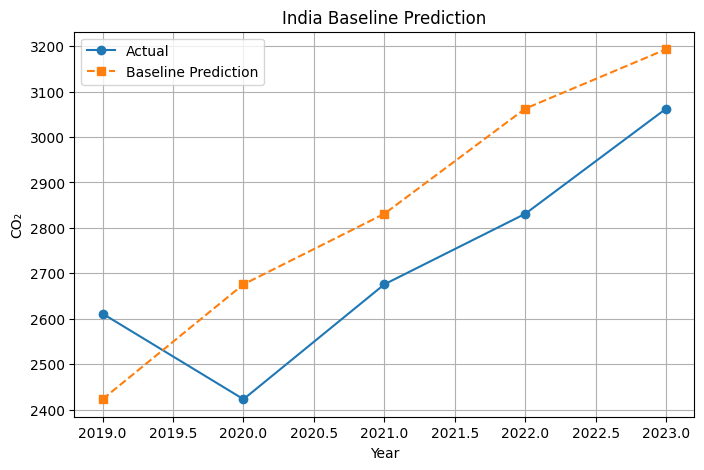

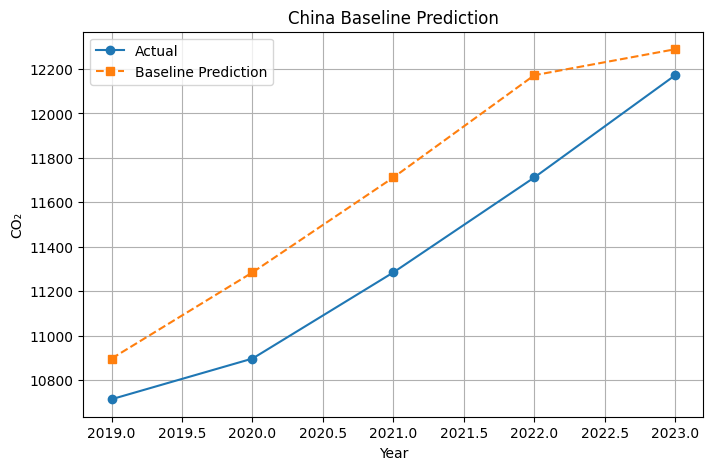

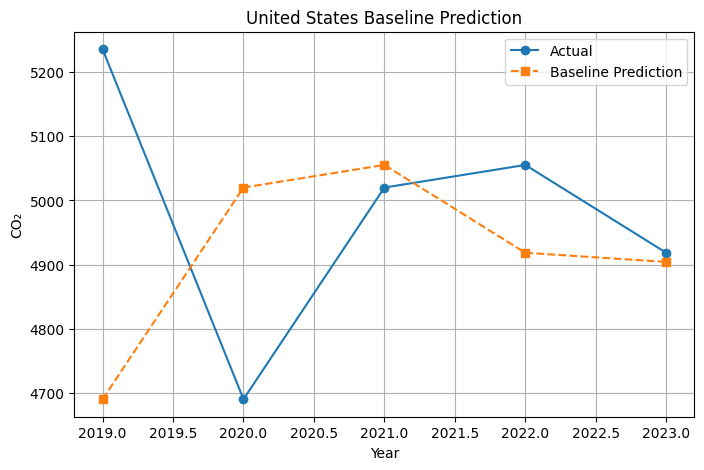

In [48]:
countries_plot = ["India","China","United States"]
import matplotlib.pyplot as plt
for country in countries_plot:
    country_test = test_df[
        test_df['country']==country
    ]
    plt.figure(figsize=(8,5))
    plt.plot(
        country_test['year'],
        country_test['co2'],
        marker='o',
        label='Actual'
    )
    plt.plot(
        country_test['year'],
        country_test['target_co2'],
        marker='s',
        linestyle='--',
        label='Baseline Prediction'
    )
    plt.title(f"{country} Baseline Prediction")
    plt.xlabel("Year")
    plt.ylabel("CO₂")
    plt.legend()
    plt.grid(True)
    plt.show()

### Interpretation

The naive baseline follows the previous year's emissions and therefore captures general trends but cannot predict sudden changes.
Large deviations are observed during years with unexpected events such as the COVID-19 pandemic.
The baseline model serves as an important benchmark for evaluating the performance of more sophisticated machine learning models.

## Linear Regression

Linear Regression is used as a simple supervised machine learning model for predicting annual CO₂ emissions.
A separate model is trained for each of the ten project countries using historical data from 1990 to 2018.
The trained model learns the relationship between engineered emission-related features and annual CO₂ emissions.
Model performance is evaluated on the 2019–2023 holdout period using MAE and RMSE.

In [49]:
from sklearn.linear_model import LinearRegression
features = [
    'year',
    'co2',
    'country_encoded',
    'co2_per_capita',
    'co2_5yr_rolling_mean',
    'co2_lag1',
    'co2_lag2',
    'co2_lag3',
    'co2_yoy_pct_change',
    'ghg_intensity'
]
model_data = df_features.dropna(subset=features + ["target_co2"]).copy()

train_df = model_data[model_data["year"] <= 2018].copy()
test_df = model_data[model_data["year"] >= 2019].copy()

X_train = train_df[features]
y_train = train_df["target_co2"]
X_test = test_df[features]
y_test = test_df["target_co2"]

In [50]:
lr_models = LinearRegression()

In [51]:
lr_models.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-1.07, 1.43,-4.83,...,-0.55,-4.17, 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['year','co2','country_encoded',...,'co2_lag3','co2_yoy_pct_change', 'ghg_intensity']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2196
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [52]:
lr_predictions = lr_models.predict(X_test)

In [53]:
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error)
import numpy as np
lr_results = []
for country in test_df["country"].unique():

    country_test = test_df[test_df["country"] == country]

    X_country = country_test[features]
    y_actual = country_test["target_co2"]
    y_pred = lr_models.predict(X_country)    

    mae = mean_absolute_error(y_actual,y_pred)
    rmse = root_mean_squared_error(y_actual,y_pred)

    lr_results.append({
        "Country": country,
        "MAE": mae,
        "RMSE": rmse
    })
lr_results = pd.DataFrame(lr_results)

lr_results

,Country,MAE,RMSE
0,Australia,6.310237,8.877551
1,Brazil,33.314417,38.379312
2,China,125.166473,138.657536
3,Germany,40.103392,47.369370
4,India,177.671420,197.597234
5,Japan,35.458283,38.107548
6,Russia,61.198194,67.474863
7,South Africa,13.729619,18.154050
8,United Kingdom,10.426842,16.077806
9,United States,288.111212,374.764262


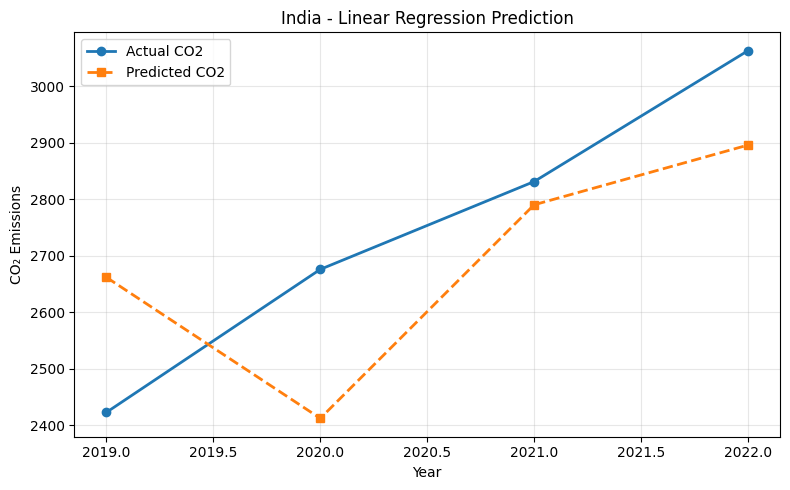

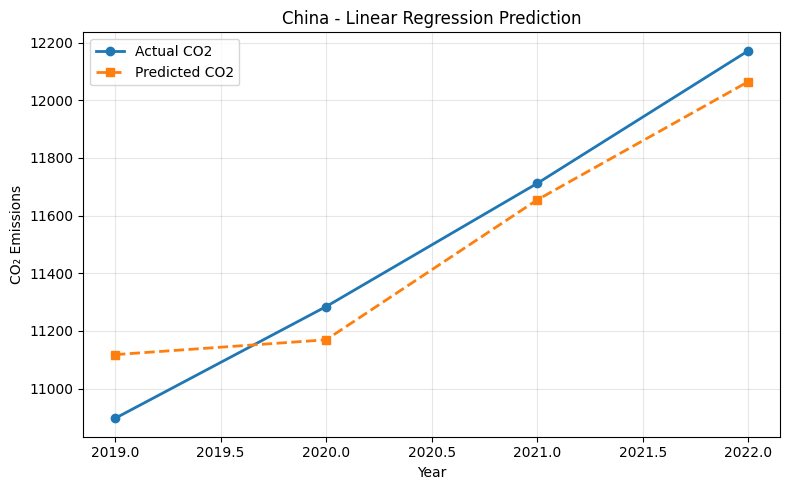

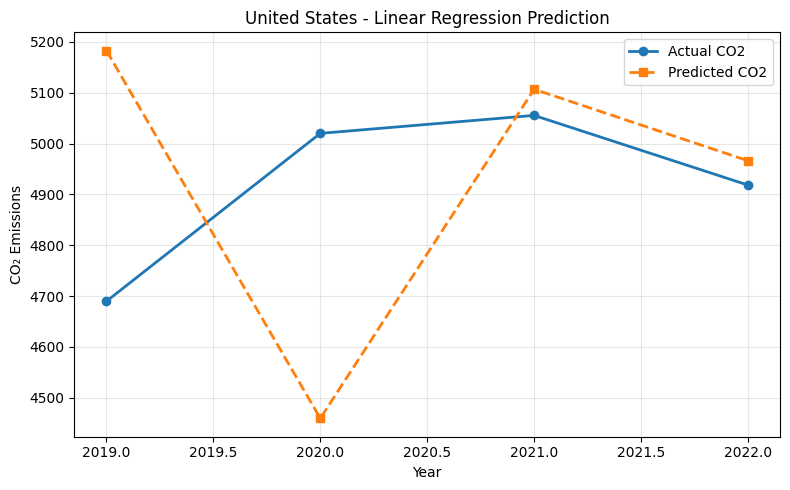

In [54]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

countries_to_plot = ["India", "China", "United States"]

for country in countries_to_plot:

    country_test = test_df[test_df["country"] == country].copy()
    
    X_country = country_test[features]
    y_test = lr_models.predict(X_country)

    plt.figure(figsize=(8,5))

    plt.plot(
        country_test["year"],
        country_test["target_co2"],
        marker="o",
        linewidth=2,
        label="Actual CO2"
    )

    plt.plot(
        country_test["year"],
        y_test,
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Predicted CO2"
    )

    plt.title(f"{country} - Linear Regression Prediction")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

### Interpretation

The Linear Regression model captures the long-term trend reasonably well for most countries. Prediction errors increase during years with unexpected changes such as the COVID-19 emissions decline.

In [55]:
lr_results

,Country,MAE,RMSE
0,Australia,6.310237,8.877551
1,Brazil,33.314417,38.379312
2,China,125.166473,138.657536
3,Germany,40.103392,47.369370
4,India,177.671420,197.597234
5,Japan,35.458283,38.107548
6,Russia,61.198194,67.474863
7,South Africa,13.729619,18.154050
8,United Kingdom,10.426842,16.077806
9,United States,288.111212,374.764262


In [56]:
baseline_results

,Country,Baseline MAE,Baseline RMSE
0,Australia,6.7002,8.887581
1,Brazil,19.7412,26.352645
2,China,315.1044,344.121882
3,Germany,39.5944,46.431112
4,India,191.8378,197.188147
5,Japan,36.5260,39.830915
6,Russia,44.2358,50.307134
7,South Africa,12.2652,17.077892
8,United Kingdom,18.8426,23.468566
9,United States,212.5380,292.332458


In [57]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr_models.coef_
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Absolute Coefficient",ascending=False )    
coef_df

,Feature,Coefficient,Absolute Coefficient
2,country_encoded,-4.833893e+00,4.833893e+00
8,co2_yoy_pct_change,-4.170027e+00,4.170027e+00
3,co2_per_capita,-3.647464e+00,3.647464e+00
1,co2,1.428723e+00,1.428723e+00
0,year,-1.069110e+00,1.069110e+00
4,co2_5yr_rolling_mean,7.885966e-01,7.885966e-01
5,co2_lag1,-7.081059e-01,7.081059e-01
7,co2_lag3,-5.517921e-01,5.517921e-01
6,co2_lag2,5.394620e-02,5.394620e-02
9,ghg_intensity,1.771815e-10,1.771815e-10


### Interpretation of Model Coefficients

Positive coefficients indicate that an increase in the feature is associated with higher predicted CO₂ emissions, while negative coefficients indicate the opposite.
Lag features generally receive high positive coefficients because previous years' emissions strongly influence future emissions.
The rolling mean captures long-term trends, whereas year-over-year percentage change reflects recent growth or decline in emissions.
These coefficients provide an interpretable view of which engineered variables contribute most to the model's predictions.

## Limitations of Per-Country Random Forest

Each country has only around 26 training observations (1990–2018), which is insufficient for training a reliable Random Forest model.
Random Forest relies on bootstrap sampling and multiple decision trees. With very small datasets, the trees become unstable, feature importance becomes unreliable, and the model is prone to overfitting.
To address this issue, a single pooled Random Forest model is trained using data from all ten project countries combined.
Pooling increases the number of training observations while allowing the model to learn cross-country relationships. However, it cannot fully capture country-specific dynamics.
This demonstrates an important machine learning principle: model complexity should match data availability.

In [58]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)

In [59]:
rf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [60]:
rf_predictions = rf.predict(X_test)
rf_predictions[:10]

array([  413.09213,   405.14108,   389.10519,   377.34223,   472.76306,
         459.3639 ,   485.26485,   471.14849, 10508.35384, 10477.01717])

In [61]:
y_pred = rf.predict(X_country)

In [62]:
from sklearn.metrics import ( mean_absolute_error,root_mean_squared_error)
rf_results = []
for country in test_df["country"].unique():

    country_test = test_df[test_df["country"] == country]

    X_country = country_test[features]
    y_actual = country_test["target_co2"]
    y_pred = rf.predict(X_country)    

    mae = mean_absolute_error(y_actual,y_pred)
    rmse = root_mean_squared_error(y_actual,y_pred)

    rf_results.append({
        "Country": country,
        "MAE": mae,
        "RMSE": rmse
    })
rf_results = pd.DataFrame(rf_results)

rf_results

,Country,MAE,RMSE
0,Australia,10.803792,11.867236
1,Brazil,20.003130,23.393505
2,China,1018.477847,1123.711948
3,Germany,80.310670,87.587442
4,India,150.540328,177.040760
5,Japan,94.090780,97.048651
6,Russia,34.425403,40.782062
7,South Africa,15.559112,19.065660
8,United Kingdom,47.009287,47.471973
9,United States,371.178308,392.646121


In [63]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=True
)
importance

,Feature,Importance
9,ghg_intensity,0.000000
2,country_encoded,0.000654
8,co2_yoy_pct_change,0.000660
0,year,0.001261
3,co2_per_capita,0.001702
7,co2_lag3,0.114711
1,co2,0.195788
5,co2_lag1,0.215327
6,co2_lag2,0.219508
4,co2_5yr_rolling_mean,0.250388


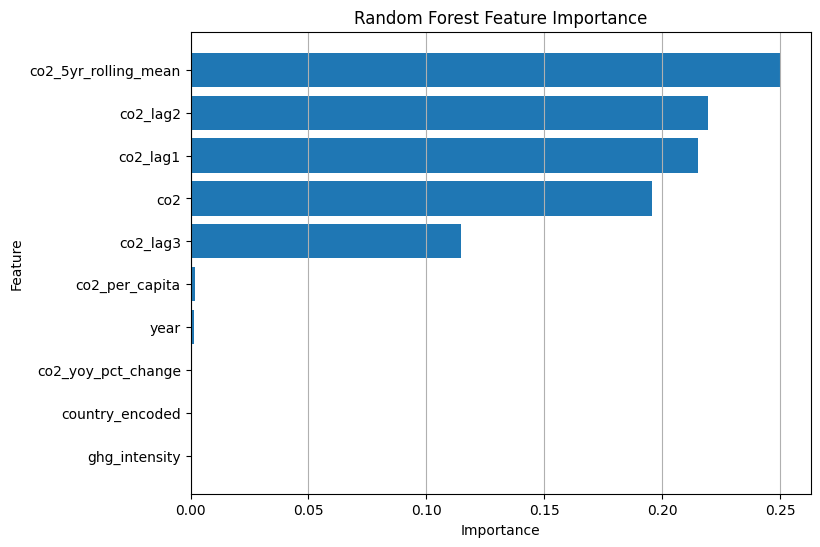

In [64]:
plt.figure(figsize=(8,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x")
plt.show()

The Random Forest model identifies the most influential features used for prediction across all countries.
Features with higher importance contribute more strongly to reducing prediction error.
Country encoding also contributes because emissions vary significantly across countries.

# Model Performance Comparison

After training the baseline models, the next step is to compare their prediction performance.
A comparison table makes it easier to evaluate which model performs better across different countries.
The evaluation uses:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
These metrics allow us to compare the Naive Baseline, Linear Regression, and Random Forest models before moving to forecasting in Week 4.

In [65]:
com_table = baseline_results.merge(lr_results,on="Country")
com_table = com_table.merge(rf_results,on="Country")
com_table

,Country,Baseline MAE,Baseline RMSE,MAE_x,RMSE_x,MAE_y,RMSE_y
0,Australia,6.7002,8.887581,6.310237,8.877551,10.803792,11.867236
1,Brazil,19.7412,26.352645,33.314417,38.379312,20.003130,23.393505
2,China,315.1044,344.121882,125.166473,138.657536,1018.477847,1123.711948
3,Germany,39.5944,46.431112,40.103392,47.369370,80.310670,87.587442
4,India,191.8378,197.188147,177.671420,197.597234,150.540328,177.040760
5,Japan,36.5260,39.830915,35.458283,38.107548,94.090780,97.048651
6,Russia,44.2358,50.307134,61.198194,67.474863,34.425403,40.782062
7,South Africa,12.2652,17.077892,13.729619,18.154050,15.559112,19.065660
8,United Kingdom,18.8426,23.468566,10.426842,16.077806,47.009287,47.471973
9,United States,212.5380,292.332458,288.111212,374.764262,371.178308,392.646121


In [66]:
baseline_df = pd.DataFrame(baseline_results)
lr_df = pd.DataFrame(lr_results)
rf_df = pd.DataFrame(rf_results)

In [67]:
baseline_df = baseline_df.rename(columns={
    "MAE": "Baseline_MAE",
    "RMSE": "Baseline_RMSE",
    "R2": "Baseline_R2"
})
lr_df = lr_df.rename(columns={
    "MAE": "LR_MAE",
    "RMSE": "LR_RMSE",
    "R2": "LR_R2"
})
rf_df = rf_df.rename(columns={
    "MAE": "RF_MAE",
    "RMSE": "RF_RMSE",
    "R2": "RF_R2"
})
print("Baseline Columns:")
print(baseline_df.columns.tolist())

print("\nLinear Regression Columns:")
print(lr_df.columns.tolist())

print("\nRandom Forest Columns:")
print(rf_df.columns.tolist())
print(len(baseline_results))
print(len(lr_results))
print(len(rf_results))

Baseline Columns:
['Country', 'Baseline MAE', 'Baseline RMSE']

Linear Regression Columns:
['Country', 'LR_MAE', 'LR_RMSE']

Random Forest Columns:
['Country', 'RF_MAE', 'RF_RMSE']
10
10
10


In [68]:
print("baseline_df columns:")
print(baseline_df.columns.tolist())

print("\nlr_df columns:")
print(lr_df.columns.tolist())

print("\nrf_df columns:")
print(rf_df.columns.tolist())

baseline_df columns:
['Country', 'Baseline MAE', 'Baseline RMSE']

lr_df columns:
['Country', 'LR_MAE', 'LR_RMSE']

rf_df columns:
['Country', 'RF_MAE', 'RF_RMSE']


In [69]:
comparison = (
    baseline_df
    .merge(lr_df, on="Country")
    .merge(rf_df, on="Country")
)
print(comparison.columns.tolist())

['Country', 'Baseline MAE', 'Baseline RMSE', 'LR_MAE', 'LR_RMSE', 'RF_MAE', 'RF_RMSE']


In [70]:
comparison["Best Model"] = comparison[[
    "Baseline MAE",
    "LR_MAE",
    "RF_MAE"]].idxmin(axis=1)

In [71]:
comparison = comparison.round(3)
comparison

,Country,Baseline MAE,Baseline RMSE,LR_MAE,LR_RMSE,RF_MAE,RF_RMSE,Best Model
0,Australia,6.700,8.888,6.310,8.878,10.804,11.867,LR_MAE
1,Brazil,19.741,26.353,33.314,38.379,20.003,23.394,Baseline MAE
2,China,315.104,344.122,125.166,138.658,1018.478,1123.712,LR_MAE
3,Germany,39.594,46.431,40.103,47.369,80.311,87.587,Baseline MAE
4,India,191.838,197.188,177.671,197.597,150.540,177.041,RF_MAE
5,Japan,36.526,39.831,35.458,38.108,94.091,97.049,LR_MAE
6,Russia,44.236,50.307,61.198,67.475,34.425,40.782,RF_MAE
7,South Africa,12.265,17.078,13.730,18.154,15.559,19.066,Baseline MAE
8,United Kingdom,18.843,23.469,10.427,16.078,47.009,47.472,LR_MAE
9,United States,212.538,292.332,288.111,374.764,371.178,392.646,Baseline MAE


In [72]:
model_data.to_csv("data/model_data.csv",index=False)

In [73]:
comparison.to_csv("data/comparison_table.csv",index=False)

In [74]:
comparison_table =  pd.read_csv("data/comparison_table.csv")
comparison_table.head()

,Country,Baseline MAE,Baseline RMSE,LR_MAE,LR_RMSE,RF_MAE,RF_RMSE,Best Model
0,Australia,6.700,8.888,6.310,8.878,10.804,11.867,LR_MAE
1,Brazil,19.741,26.353,33.314,38.379,20.003,23.394,Baseline MAE
2,China,315.104,344.122,125.166,138.658,1018.478,1123.712,LR_MAE
3,Germany,39.594,46.431,40.103,47.369,80.311,87.587,Baseline MAE
4,India,191.838,197.188,177.671,197.597,150.540,177.041,RF_MAE


### Model Comparison

The performance of the Baseline, Linear Regression, and Random Forest models was compared using MAE and RMSE.
For Australia, the Linear Regression model achieved the lowest prediction error with an MAE of 0.879 and an RMSE of 1.008, outperforming both the Baseline and Random Forest models.
The Random Forest model produced higher prediction errors, indicating that it was less suitable for this relatively small time-series dataset.
Overall, Linear Regression provided the best predictive performance among the evaluated models.